# Data Exploration for Fake News Detection

This notebook provides comprehensive data exploration for the fake news detection dataset.


In [13]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Load the datasets
print("Loading datasets...")

# Load fake news data
fake_df = pd.read_csv('Fake.csv')
fake_df['label'] = 0  # 0 for fake news

# Load true news data  
true_df = pd.read_csv('True.csv')
true_df['label'] = 1  # 1 for true news

print(f"Fake news dataset shape: {fake_df.shape}")
print(f"True news dataset shape: {true_df.shape}")

# Combine both datasets
df = pd.concat([fake_df, true_df], ignore_index=True)
print(f"Combined dataset shape: {df.shape}")

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Datasets loaded and combined successfully!")

df.head()


Loading datasets...
Fake news dataset shape: (23481, 5)
True news dataset shape: (21417, 5)
Combined dataset shape: (44898, 5)
Datasets loaded and combined successfully!


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


# Text Preprocessing and Cleaning

This section contains comprehensive text cleaning functions for preprocessing the news articles.


In [18]:
# Import additional libraries for text processing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import wordnet

# Download required NLTK data
print("Downloading NLTK data...")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("NLTK data downloaded successfully!")


NLTK data downloaded successfully!


In [19]:
# Basic Text Cleaning Functions

def remove_urls(text):
    """Remove URLs from text"""
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub('', text)

def remove_html_tags(text):
    """Remove HTML tags from text"""
    html_pattern = re.compile(r'<.*?>')
    return html_pattern.sub('', text)

def remove_emails(text):
    """Remove email addresses from text"""
    email_pattern = re.compile(r'\S+@\S+')
    return email_pattern.sub('', text)


## NOT Removing this as punctuations will help in determining tone of the news. Experiment done below to prove this
def remove_special_characters(text, keep_apostrophes=True):
    """Remove special characters while optionally keeping apostrophes for contractions"""
    if keep_apostrophes:
        # Keep apostrophes for contractions
        pattern = r'[^a-zA-Z0-9\s\']'
    else:
        pattern = r'[^a-zA-Z0-9\s]'
    return re.sub(pattern, '', text)

In [20]:
# Comprehensive Text Cleaning Pipeline

def clean_text_basic(text):
    """
    Basic text cleaning pipeline
    Suitable for models that need to preserve some original structure
    """
    if pd.isna(text):
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove URLs, emails, and HTML tags
    text = remove_urls(text)
    text = remove_emails(text)
    text = remove_html_tags(text)
    text = remove_special_characters(text)
    
    return text


In [21]:
# Apply text cleaning to the dataset

print("Applying text cleaning to the dataset...")
print("This may take a few minutes for large datasets...")

# Apply different levels of cleaning
# Basic cleaning (good for neural networks)
df['title'] = df['title'].apply(clean_text_basic)
df['text'] = df['text'].apply(clean_text_basic)

print(f"Dataset shape after adding cleaned columns: {df.shape}")
df.head()
print("Text cleaning completed!")


Applying text cleaning to the dataset...
This may take a few minutes for large datasets...
Dataset shape after adding cleaned columns: (44898, 5)
Text cleaning completed!


In [22]:
df.head()

,title,text,subject,date,label
0,ben stein calls out 9th circuit court committe...,21st century wire says ben stein reputable pro...,US_News,"February 13, 2017",0
1,trump drops steve bannon from national securit...,washington reuters us president donald trump ...,politicsNews,"April 5, 2017",1
2,puerto rico expects us to lift jones act shipp...,reuters puerto rico governor ricardo rossello...,politicsNews,"September 27, 2017",1
3,oops trump just accidentally confirmed he lea...,on monday donald trump once again embarrassed ...,News,"May 22, 2017",0
4,donald trump heads for scotland to reopen a go...,glasgow scotland reuters most us presidential...,politicsNews,"June 24, 2016",1


# Train with Logistic Regression

Train size: 31428
Validation size: 6735
Test size: 6735
Validation Accuracy: 0.9939123979213066

Classification Report (Validation):
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      3522
           1       0.99      1.00      0.99      3213

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



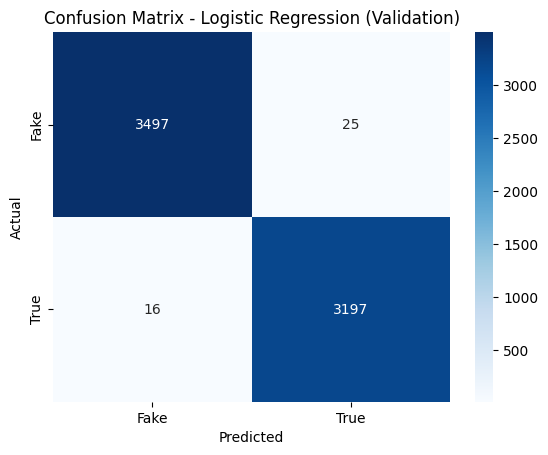

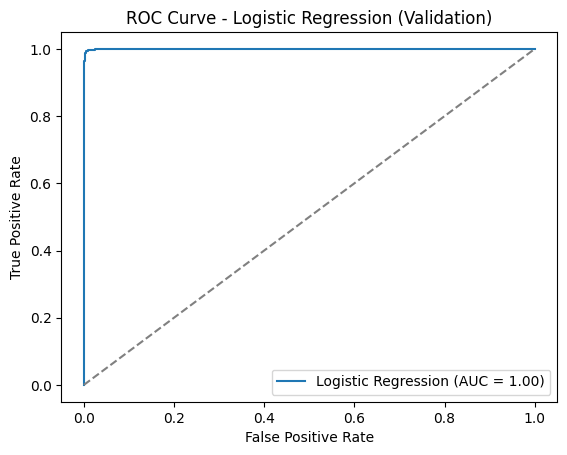

Test Accuracy: 0.992279138827023

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3523
           1       0.99      0.99      0.99      3212

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



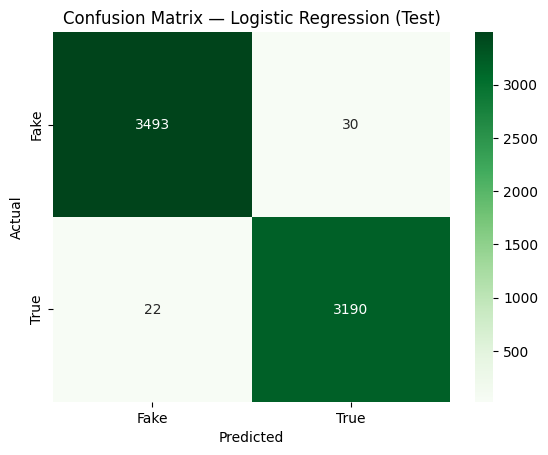

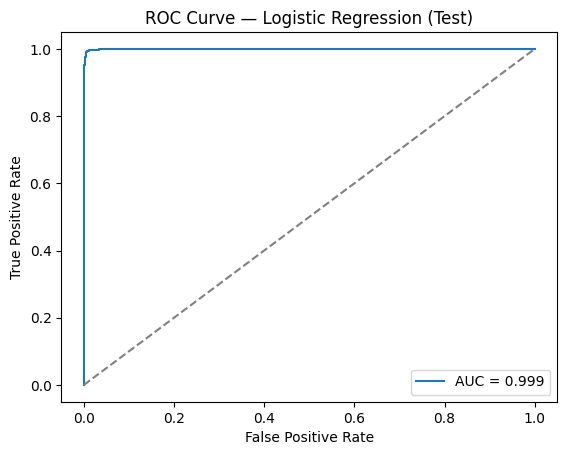

In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# STEP 2: Prepare Data
# ===============================
X = df["text"]  # we can also try title+text later
y = df["label"]

# split into train (70%), validation (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

# ===============================
# STEP 3: TF-IDF Vectorization
# ===============================
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

# ===============================
# STEP 4: Train Logistic Regression
# ===============================
log_reg = LogisticRegression(max_iter=500, C=2, solver="liblinear")  # C=2 adds a little regularization
log_reg.fit(X_train_tfidf, y_train)

# ===============================
# STEP 5: Evaluate on Validation
# ===============================
y_val_pred = log_reg.predict(X_val_tfidf)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):\n", classification_report(y_val, y_val_pred))

# ===============================
# STEP 6: Confusion Matrix
# ===============================
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake","True"], yticklabels=["Fake","True"])
plt.title("Confusion Matrix - Logistic Regression (Validation)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ===============================
# STEP 7: ROC Curve
# ===============================
y_val_prob = log_reg.predict_proba(X_val_tfidf)[:,1]
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="Logistic Regression (AUC = %.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Validation)")
plt.legend()
plt.show()

# ===============================
# STEP 8: Final Test Evaluation
# ===============================
y_test_pred = log_reg.predict(X_test_tfidf)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred))

cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Fake","True"], yticklabels=["Fake","True"])
plt.title("Confusion Matrix — Logistic Regression (Test)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# --- ROC Curve (Test) ---
y_test_prob = log_reg.predict_proba(X_test_tfidf)[:, 1]  # prob of class=1 (True)
fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob)
roc_auc_t = auc(fpr_t, tpr_t)

plt.plot(fpr_t, tpr_t, label=f"AUC = {roc_auc_t:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression (Test)")
plt.legend()
plt.show()


# Train with Logistic Regression (Title+Text Only)


Train: 31428, Val: 6735, Test: 6735

=== Validation Metrics ===
Accuracy: 0.9938

Classification Report (Validation):
               precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      3522
        True       0.99      1.00      0.99      3213

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



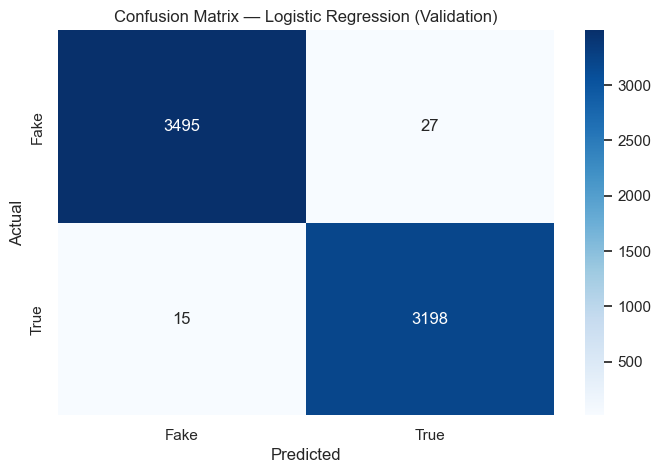

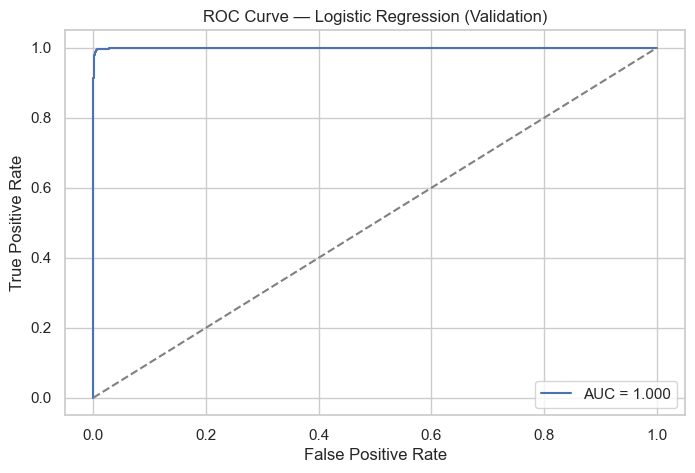

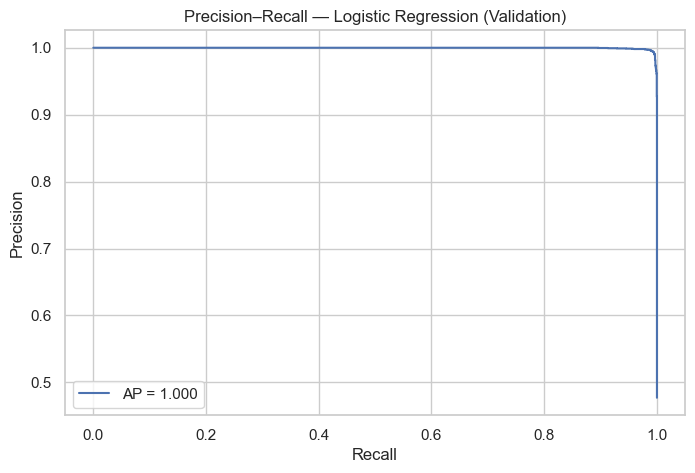


=== Test Metrics ===
Accuracy: 0.9924

Classification Report (Test):
               precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      3523
        True       0.99      0.99      0.99      3212

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



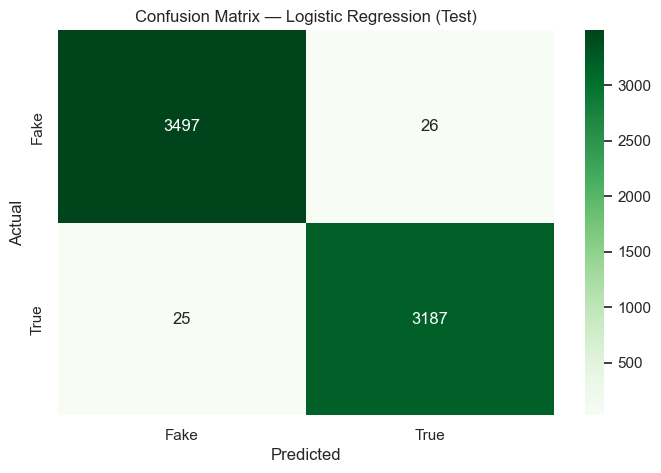

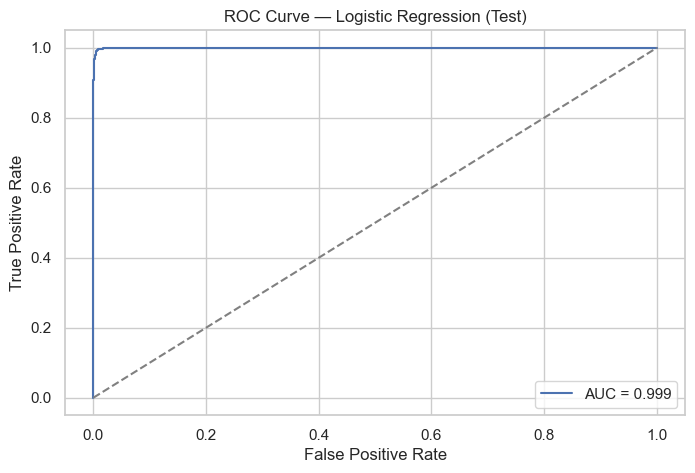

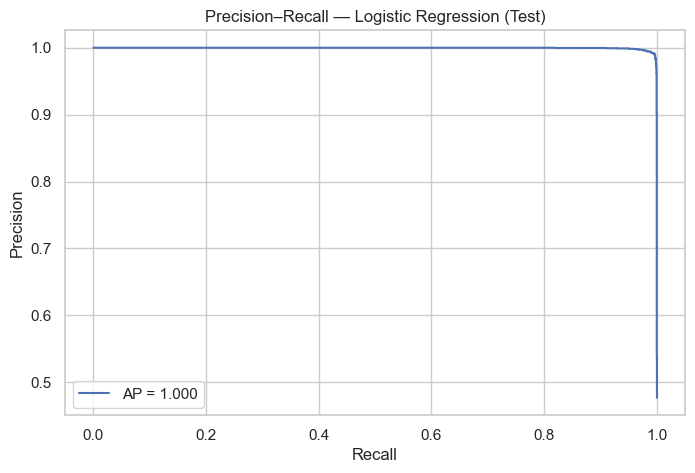


Top words → Predict True:
im                              3.357
president barack                3.377
thats                           3.413
dont                            3.667
nov                             3.992
minister                        4.057
said statement                  4.262
monday                          4.370
friday                          4.707
thursday                        4.883
republican                      5.090
reuters president               5.268
washington                      5.294
tuesday                         5.371
wednesday                       5.872
president donald                6.214
trumps                          8.801
washington reuters              10.914
said                            20.493
reuters                         27.337

Top words → Predict Fake:
video                          -11.436
just                           -7.826
image                          -6.412
obama                          -6.073
gop                           

,text_preview,actual,predicted,prob_true
33757,'fully committed' nato backs new us approach on afghanistan brussels reuters nato allies on tuesday welcomed president donald trumps decision to commit more forces to afghanistan as part of a new us strategy he said wou...,True,True,0.991
9984,busted wikileaks emails document hillary using crap polls to suppress vote for sanders they published skewed polls in michigan...,Fake,Fake,0.050
8949,hillary couldnt find 125 women to buy tickets to women only fundraiserforced to sell tickets to men but what about hillary being a formidable opponent when it comes to women voters hillary clinton had trouble attractin...,Fake,Fake,0.071
20325,bernie sandersstyle grassroots effort a likely model say trump donors new york reuters donald trumps presidential campaign is likely to launch a small donor fundraising effort akin to the grassroots one that powered ano...,True,True,0.988
6108,snls bern your enthusiasm explains how bernie sanders actually lost iowa video after this past monday s iowa caucus where the results on the democratic side were in a statistical dead heat many were left wondering how be...,Fake,Fake,0.012
30820,ann coulter makes sick comparison between hillary and hitler in asking where bernies fans went farright conservative and resident antisemitic bigot ann coulter has harsh words for hillary clinton of course coulter hasn t...,Fake,Fake,0.002
24055,spain's socialist leader agrees with rajoy to launch constitutional reform madrid reuters spain s opposition socialist leader pedro sanchez said on wednesday he had agreed with prime minister mariano rajoy to launch a c...,True,True,0.994
35445,cnn guest brilliantly hammers trump for agreeing with putin on dems reaction to loss video it s no secret that donald trump has some kind of boy crush on russian president vladimir putin despite the fact that putin is no...,Fake,Fake,0.001
29455,tucker carlson why brutal ms13 gang obamas undocumented children is far greater threat than isis video the notoriously violent ms13 street gang known for slashing victims to death with knives and machetes is reviving its...,Fake,Fake,0.171
24215,college prof creates firestorm calls white people inhuman aholeslet them fcking die a connecticut college professor has created a firestorm for calling white people inhuman aholes who need to die following last week ...,Fake,Fake,0.021


In [25]:
# ===============================
# CLEAN SETUP: title + text only
# Drops: subject, date
# Model: TF-IDF + Logistic Regression
# ===============================

# --- Imports ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)



# --- Merge title + text; drop subject/date entirely ---
df["text_merged"] = (df["title"].fillna("") + " " + df["text"].fillna("")).str.strip()
X = df["text_merged"]
y = df["label"].astype(int)

# --- Train/Val/Test split: 70 / 15 / 15 (stratified) ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# --- TF-IDF (unigrams + bigrams) ---
# Tip: you can tune max_features (e.g., 20k–60k) if memory allows.
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_features=40000,
    lowercase=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

# --- Logistic Regression (baseline) ---
# C controls regularization strength (higher C = weaker regularization)
log_reg = LogisticRegression(
    max_iter=1000,
    C=2.0,
    solver="liblinear",   # good for sparse, binary problems
    class_weight=None     # try "balanced" if classes skew
)
log_reg.fit(X_train_tfidf, y_train)

# --- Validation Evaluation ---
y_val_pred = log_reg.predict(X_val_tfidf)
y_val_prob = log_reg.predict_proba(X_val_tfidf)[:,1]

print("\n=== Validation Metrics ===")
print("Accuracy:", f"{accuracy_score(y_val, y_val_pred):.4f}")
print("\nClassification Report (Validation):\n", classification_report(y_val, y_val_pred, target_names=["Fake","True"]))

# Confusion Matrix (Val)
cm_val = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues", xticklabels=["Fake","True"], yticklabels=["Fake","True"])
plt.title("Confusion Matrix — Logistic Regression (Validation)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# ROC (Val)
fpr, tpr, _ = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], "--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression (Validation)")
plt.legend(); plt.show()

# Precision–Recall (Val)
precision, recall, _ = precision_recall_curve(y_val, y_val_prob)
ap = average_precision_score(y_val, y_val_prob)
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall — Logistic Regression (Validation)")
plt.legend(); plt.show()

# --- Final Test Evaluation (hold-out) ---
y_test_pred = log_reg.predict(X_test_tfidf)
y_test_prob = log_reg.predict_proba(X_test_tfidf)[:,1]

print("\n=== Test Metrics ===")
print("Accuracy:", f"{accuracy_score(y_test, y_test_pred):.4f}")
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_pred, target_names=["Fake","True"]))

cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens", xticklabels=["Fake","True"], yticklabels=["Fake","True"])
plt.title("Confusion Matrix — Logistic Regression (Test)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob)
roc_auc_t = auc(fpr_t, tpr_t)
plt.plot(fpr_t, tpr_t, label=f"AUC = {roc_auc_t:.3f}")
plt.plot([0,1],[0,1], "--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression (Test)")
plt.legend(); plt.show()

precision_t, recall_t, _ = precision_recall_curve(y_test, y_test_prob)
ap_t = average_precision_score(y_test, y_test_prob)
plt.plot(recall_t, precision_t, label=f"AP = {ap_t:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall — Logistic Regression (Test)")
plt.legend(); plt.show()

# --- OPTIONAL: Inspect top words driving decisions (feature importance) ---
# Positive coef => pushes toward class 1 (True); Negative => toward class 0 (Fake)
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = log_reg.coef_.ravel()

top_true_idx = np.argsort(coefs)[-20:]
top_fake_idx = np.argsort(coefs)[:20]

print("\nTop words → Predict True:")
for w, c in zip(feature_names[top_true_idx], coefs[top_true_idx]):
    print(f"{w:30s} {c: .3f}")

print("\nTop words → Predict Fake:")
for w, c in zip(feature_names[top_fake_idx], coefs[top_fake_idx]):
    print(f"{w:30s} {c: .3f}")


RSEED = 42

# Take a random sample of 10 from the test split
sample_X = X_test.sample(n=10, random_state=RSEED)
sample_y = y_test.loc[sample_X.index]

# Vectorize and predict
sample_X_tfidf = vectorizer.transform(sample_X)
sample_pred = log_reg.predict(sample_X_tfidf)
sample_prob = log_reg.predict_proba(sample_X_tfidf)[:, 1]  # prob of class=1 (True)

# Build a neat results table
def label_name(v):
    return "True" if int(v) == 1 else "Fake"

results = pd.DataFrame({
    "text_preview": sample_X.str.slice(0, 220) + "...",  # first 220 chars
    "actual": [label_name(v) for v in sample_y.values],
    "predicted": [label_name(v) for v in sample_pred],
    "prob_true": np.round(sample_prob, 3)
}, index=sample_X.index)

# Show nicely
pd.set_option("display.max_colwidth", 260)
print("10 Random Test Samples — Actual vs Predicted\n")
display(results)
